# Proposal: high-fidelity antenna model as an OSI radar extension

### 1. Antenna definition with the `antenna.element` API (mirrors OSI)

Same recipe as `notebooks/antenna/application_ula_array.ipynb`, but now with

- one Tx element and an 8-element Rx ULA with λ/2 spacing,
- elements placed along **y** of the OSI sensor frame (x = boresight, y = left), so the array resolves azimuth,
- a −20 dB cross-polar leakage (`pattern_01`, `pattern_10`) so that polarization effects become visible.

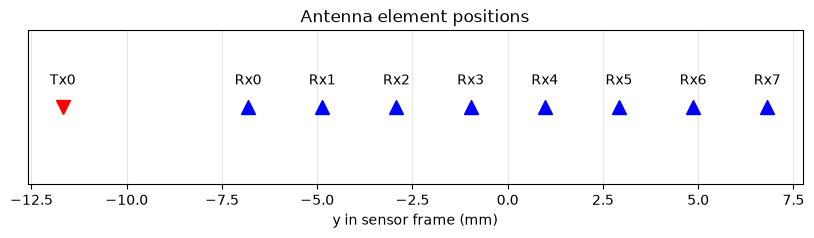

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from antenna.element import (
    SPEED_OF_LIGHT,
    AntennaElement,
    AntennaElementType,
    AntennaModel,
    ComplexGrid,
    FrequencyInstance,
    JonesPattern,
    Mode,
    PolarizationBasis,
    Vector3d,
    simple_grid,
    zero_grid,
)

FREQUENCY = 77e9
WAVELENGTH = SPEED_OF_LIGHT / FREQUENCY
TX_TYPE, RX_TYPE = 0, 1

horizontal_angle = np.radians(np.linspace(-90, 90, 1001))
vertical_angle = np.radians(np.linspace(-90, 90, 1001))

base_grid = simple_grid(horizontal_angle, vertical_angle)
zero = zero_grid(horizontal_angle, vertical_angle)
cross_polar_grid = ComplexGrid(amplitude=0.1 * base_grid.amplitude, phase=zero.phase)

radiation = JonesPattern(
    horizontal_angle=horizontal_angle,
    vertical_angle=vertical_angle,
    pattern_00=base_grid,
    pattern_11=zero,
    pattern_01=cross_polar_grid,
    pattern_10=cross_polar_grid,
)
frequency_instance = FrequencyInstance(frequency=FREQUENCY, gain=20.0, phase=0.0, radiation=radiation)

element_types = [
    AntennaElementType(id=TX_TYPE, mode=Mode.TRANSMIT, frequency_instance=[frequency_instance]),
    AntennaElementType(id=RX_TYPE, mode=Mode.RECEIVE, frequency_instance=[frequency_instance]),
]

number_of_rx = 8
rx_y = (np.arange(number_of_rx) - (number_of_rx - 1) / 2) * 0.5 * WAVELENGTH

elements = [AntennaElement(index=0, element_type_id=TX_TYPE, position=Vector3d(0.0, -3 * WAVELENGTH, 0.0))]
elements += [
    AntennaElement(index=i, element_type_id=RX_TYPE, position=Vector3d(0.0, y, 0.0))
    for i, y in enumerate(rx_y)
]

antenna_model = AntennaModel(
    id=0,
    polarization_basis=PolarizationBasis.LINEAR_HV,
    element_type=element_types,
    element=elements,
)

fig, ax = plt.subplots(figsize=(10, 2))
for e in antenna_model.element:
    tx = antenna_model.type_of(e).mode == Mode.TRANSMIT
    ax.plot(e.position.y * 1e3, 0, "rv" if tx else "b^", markersize=10)
    ax.annotate(f"{'Tx' if tx else 'Rx'}{e.index}", (e.position.y * 1e3, 0.3), ha="center")
ax.set_xlabel("y in sensor frame (mm)")
ax.set_yticks([])
ax.set_ylim(-1, 1)
ax.set_title("Antenna element positions")
ax.grid(True, alpha=0.3)
plt.show()

### 2. Serialise into `osi3.AntennaModel`

The Python model already has the OSI structure and units, so `to_proto` / `from_proto` only copy fields (see `docs/osi_antenna_extension.md`).

The pattern is stored once per `AntennaElementType`, not once per channel. The pattern grid resolution is the main size driver; `AntennaModel.resampled(step)` reduces it before serialisation:

In [2]:
from antenna.element import Direction
from osi3 import osi_antenna_pb2
from osi_hfss.antenna_adapter import from_proto, to_proto

rng = np.random.default_rng(0)
test_directions = [Direction(h, v) for h, v in zip(np.radians(rng.uniform(-60, 60, 300)),
                                                   np.radians(rng.uniform(-10, 10, 300)))]
rx0 = antenna_model.element[1]
reference = np.array([antenna_model.jones(rx0, FREQUENCY, d) for d in test_directions])

print(f"{'grid step':>10} {'grid':>9} {'size':>9} {'max |ΔJ| / max|J|':>18}")
for step in (0.5, 1.0, 2.0, 5.0):
    message = to_proto(antenna_model.resampled(np.radians(step)))
    rebuilt = from_proto(osi_antenna_pb2.AntennaModel.FromString(message.SerializeToString()))
    approx = np.array([rebuilt.jones(rebuilt.element[1], FREQUENCY, d) for d in test_directions])
    jones = message.element_type[0].frequency_instance[0].radiation
    print(f"{step:9.1f}° {len(jones.horizontal_angle):4d}x{len(jones.vertical_angle):<4d} "
          f"{message.ByteSize() / 1e6:7.2f}MB {np.abs(approx - reference).max() / np.abs(reference).max():18.3f}")

 grid step      grid      size  max |ΔJ| / max|J|
      0.5°  361x361    16.69MB              0.004
      1.0°  181x181     4.20MB              0.010
      2.0°   91x91      1.06MB              0.019
      5.0°   37x37      0.18MB              0.046


The lookup is nearest-neighbour, so the error is the grid quantisation; interpolation in the sensor model would reduce it. 2° is used below as a compromise. For large arrays with many element types an external pattern reference (file / URI) might be preferable — see open questions at the end.

The `RadarSensorViewConfiguration` now carries the model, `antenna_application = SENSOR_MODEL`, and — for backward compatibility — the legacy diagrams **derived** from the model.

RadarSensorViewConfiguration: 1.20 MB (antenna_model 1.06 MB)


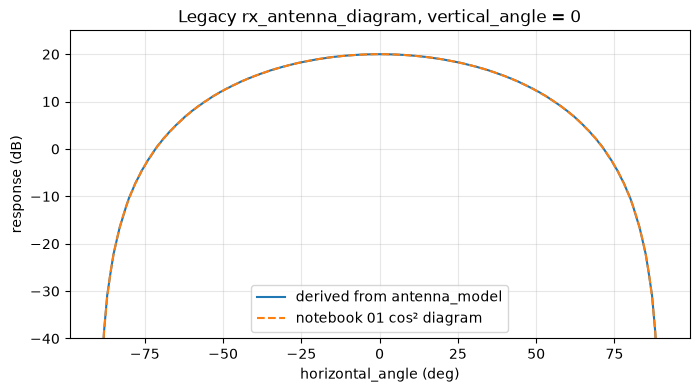

In [3]:
from osi3 import osi_sensorviewconfiguration_pb2
from osi_hfss import toy_env
from osi_hfss.antenna_adapter import to_legacy_diagram

SENSOR_ID = 100
RadarConfig = osi_sensorviewconfiguration_pb2.RadarSensorViewConfiguration

sensor_view_configuration = osi_sensorviewconfiguration_pb2.SensorViewConfiguration()
sensor_view_configuration.version.CopyFrom(toy_env.interface_version())
sensor_view_configuration.sensor_id.value = SENSOR_ID
sensor_view_configuration.mounting_position.position.x = 3.5
sensor_view_configuration.mounting_position.position.z = 0.5
sensor_view_configuration.field_of_view_horizontal = np.radians(120.0)
sensor_view_configuration.field_of_view_vertical = np.radians(20.0)

radar_config = sensor_view_configuration.radar_sensor_view_configuration.add()
radar_config.sensor_id.value = SENSOR_ID
radar_config.mounting_position.CopyFrom(sensor_view_configuration.mounting_position)
radar_config.field_of_view_horizontal = np.radians(120.0)
radar_config.field_of_view_vertical = np.radians(20.0)
radar_config.number_of_rays_horizontal = 256
radar_config.number_of_rays_vertical = 16
radar_config.max_number_of_interactions = 1
radar_config.emitter_frequency = FREQUENCY

# New fields
radar_config.antenna_model.CopyFrom(to_proto(antenna_model.resampled(np.radians(2.0))))
radar_config.antenna_application = RadarConfig.ANTENNA_APPLICATION_SENSOR_MODEL

# Legacy fields, derived from the detailed model
diagram_h = np.radians(np.arange(-90.0, 90.1, 1.0))
diagram_v = np.radians(np.arange(-30.0, 30.1, 5.0))
radar_config.tx_antenna_diagram.extend(
    to_legacy_diagram(antenna_model, antenna_model.element[0], FREQUENCY, diagram_h, diagram_v)
)
radar_config.rx_antenna_diagram.extend(
    to_legacy_diagram(antenna_model, antenna_model.element[1], FREQUENCY, diagram_h, diagram_v)
)

# Same cos² element as in notebook 01 -> the derived legacy diagram must match it
expected = np.array([20.0 + max(20 * np.log10(np.cos(h) ** 2 * np.cos(v) ** 2), -80.0)
                     for h in diagram_h for v in diagram_v])
derived = np.array([e.response for e in radar_config.rx_antenna_diagram])
valid = expected > -20
assert np.abs(derived - expected)[valid].max() < 0.5
print(f"RadarSensorViewConfiguration: {radar_config.ByteSize() / 1e6:.2f} MB "
      f"(antenna_model {radar_config.antenna_model.ByteSize() / 1e6:.2f} MB)")

fig, ax = plt.subplots(figsize=(8, 4))
cut = len(diagram_v) // 2
ax.plot(np.degrees(diagram_h), derived.reshape(len(diagram_h), -1)[:, cut], label="derived from antenna_model")
ax.plot(np.degrees(diagram_h), expected.reshape(len(diagram_h), -1)[:, cut], "--", label="notebook 01 cos² diagram")
ax.set_ylim(-40, 25)
ax.set_xlabel("horizontal_angle (deg)")
ax.set_ylabel("response (dB)")
ax.set_title("Legacy rx_antenna_diagram, vertical_angle = 0")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

### 3. Environment simulation → `SensorView` with polarimetric reflections

In [4]:
from osi3 import osi_sensorview_pb2

ground_truth = toy_env.make_ground_truth()

sensor_view = osi_sensorview_pb2.SensorView()
sensor_view.version.CopyFrom(toy_env.interface_version())
sensor_view.timestamp.CopyFrom(ground_truth.timestamp)
sensor_view.sensor_id.value = SENSOR_ID
sensor_view.mounting_position.CopyFrom(radar_config.mounting_position)
sensor_view.host_vehicle_id.CopyFrom(ground_truth.host_vehicle_id)
sensor_view.global_ground_truth.CopyFrom(ground_truth)
radar_sensor_view = sensor_view.radar_sensor_view.add()
radar_sensor_view.view_configuration.CopyFrom(radar_config)
radar_sensor_view.reflection.extend(toy_env.hfss_reflections(radar_config, ground_truth))

payload = sensor_view.SerializeToString()
received_sensor_view = osi_sensorview_pb2.SensorView.FromString(payload)
assert received_sensor_view == sensor_view
print(f"SensorView: {len(payload) / 1e6:.2f} MB\n")

print(f"{'signal [dB]':>12} {'dep h [deg]':>12} {'arr h [deg]':>12}  polarimetric_response / sqrt(path gain)")
for r in radar_sensor_view.reflection:
    S = toy_env.jones_from_osi(r.polarimetric_response)
    print(f"{r.signal_strength:12.1f} {np.degrees(r.source_horizontal_angle):12.1f} "
          f"{np.degrees(r.arrival_horizontal_angle):12.1f}  {np.round(S / 10 ** (r.signal_strength / 20), 2).tolist()}")

SensorView: 1.20 MB

 signal [dB]  dep h [deg]  arr h [deg]  polarimetric_response / sqrt(path gain)
      -132.0        -27.0        -27.0  [[(1+0j), 0j], [0j, (1+0j)]]
      -139.3          5.6          5.6  [[(1+0j), 0j], [0j, (1+0j)]]
      -126.9         33.0         33.0  [[(1+0j), 0j], [0j, (1+0j)]]


### 4. Sensor model: apply the antenna, synthesise channels, estimate angles

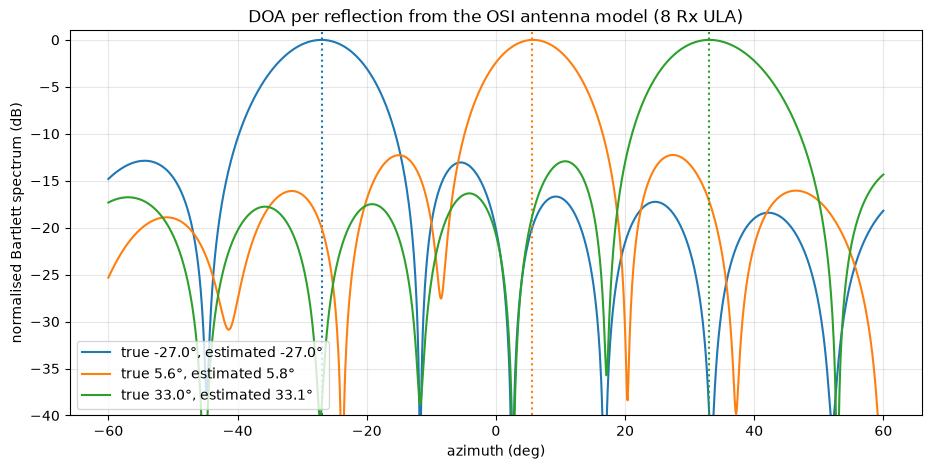

In [5]:
from antenna.ula import ULA

TX_POWER_DBM = 12.0
NOISE_POWER_DBM = -110.0

received_config = received_sensor_view.radar_sensor_view[0].view_configuration
assert received_config.antenna_application == RadarConfig.ANTENNA_APPLICATION_SENSOR_MODEL

sensor_antenna = from_proto(received_config.antenna_model)
tx_elements = sensor_antenna.elements(Mode.TRANSMIT)
rx_elements = sensor_antenna.elements(Mode.RECEIVE)
frequency = received_config.emitter_frequency
k = 2 * np.pi * frequency / SPEED_OF_LIGHT
ula = ULA(sensor_antenna, frequency, Mode.RECEIVE)


def rx_snapshot(reflection, rng, tx_excitation=np.array([1.0, 0.0])):
    S = toy_env.jones_from_osi(reflection.polarimetric_response)
    departure = Direction(reflection.source_horizontal_angle, reflection.source_vertical_angle)
    arrival = Direction(reflection.arrival_horizontal_angle, reflection.arrival_vertical_angle)
    tx = tx_elements[0]
    field = (sensor_antenna.response(tx, frequency, departure, tx_excitation)
             * np.exp(1j * k * tx.position.to_array() @ departure.unit_vector()))
    scattered = S @ field
    y = np.array([
        sensor_antenna.receive(rx, frequency, arrival, scattered)[0]
        * np.exp(1j * k * rx.position.to_array() @ arrival.unit_vector())
        for rx in rx_elements
    ])
    y *= np.sqrt(10 ** (TX_POWER_DBM / 10)) * np.exp(-2j * np.pi * frequency * reflection.time_of_flight)
    noise_std = np.sqrt(10 ** (NOISE_POWER_DBM / 10) / 2)
    return y + noise_std * (rng.standard_normal(len(y)) + 1j * rng.standard_normal(len(y)))


scan_deg = np.arange(-60.0, 60.0 + 1e-9, 0.1)
steering = np.array([ula.element_response_vector(np.radians(a)) for a in scan_deg])  # (angles, channels)
steering_norm2 = np.sum(np.abs(steering) ** 2, axis=1)


def bartlett(y):
    return np.abs(steering.conj() @ y) ** 2 / steering_norm2


rng = np.random.default_rng(1)
reflections = received_sensor_view.radar_sensor_view[0].reflection
snapshots = [rx_snapshot(r, rng) for r in reflections]
spectra = [bartlett(y) for y in snapshots]

fig, ax = plt.subplots(figsize=(11, 5))
for r, p in zip(reflections, spectra):
    line, = ax.plot(scan_deg, 10 * np.log10(p / p.max()),
                    label=f"true {np.degrees(r.arrival_horizontal_angle):.1f}°, estimated {scan_deg[np.argmax(p)]:.1f}°")
    ax.axvline(np.degrees(r.arrival_horizontal_angle), color=line.get_color(), linestyle=":")
ax.set_ylim(-40, 1)
ax.set_xlabel("azimuth (deg)")
ax.set_ylabel("normalised Bartlett spectrum (dB)")
ax.set_title("DOA per reflection from the OSI antenna model (8 Rx ULA)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

The detections now carry an **estimated** azimuth, an SNR that includes the array gain, and an RCS measured from the beamformed power. The linear array cannot resolve elevation, so it is reported as 0.

In [6]:
from osi3 import osi_featuredata_pb2, osi_sensordata_pb2

SNR_THRESHOLD_DB = 10.0
noise_mw = 10 ** (NOISE_POWER_DBM / 10)
tx_mw = 10 ** (TX_POWER_DBM / 10)

sensor_data = osi_sensordata_pb2.SensorData()
sensor_data.version.CopyFrom(toy_env.interface_version())
sensor_data.timestamp.CopyFrom(received_sensor_view.timestamp)
sensor_data.sensor_id.value = SENSOR_ID
sensor_data.mounting_position.CopyFrom(received_config.mounting_position)
radar_data = sensor_data.feature_data.radar_sensor.add()
radar_data.header.measurement_time.CopyFrom(received_sensor_view.timestamp)
radar_data.header.sensor_id.value = SENSOR_ID
radar_data.header.mounting_position.CopyFrom(received_config.mounting_position)
radar_data.header.data_qualifier = osi_featuredata_pb2.SensorDetectionHeader.DATA_QUALIFIER_AVAILABLE

print(f"{'range [m]':>10} {'true az':>8} {'est. az':>8} {'error':>7} {'rcs [dBsm]':>11} {'snr [dB]':>9}")
for r, y, p in zip(reflections, snapshots, spectra):
    peak = int(np.argmax(p))
    snr = 10 * np.log10(p[peak] / noise_mw)
    if snr < SNR_THRESHOLD_DB:
        continue
    distance = SPEED_OF_LIGHT * r.time_of_flight / 2
    azimuth = np.radians(scan_deg[peak])
    # |a^H y|^2 / |a|^4 = P_tx |c|^2 |J_tx|^2  ->  co-polar channel power |c|^2  ->  RCS
    tx_gain = np.abs(sensor_antenna.jones(tx_elements[0], frequency, Direction(azimuth, 0.0))[0, 0]) ** 2
    channel_power = p[peak] / steering_norm2[peak] / (tx_mw * tx_gain)
    rcs = 10 * np.log10(channel_power) - toy_env.path_gain_db(frequency, 0.0, distance)

    detection = radar_data.detection.add()
    detection.existence_probability = 1.0
    detection.position.distance = distance
    detection.position.azimuth = azimuth  # estimated
    detection.position.elevation = 0.0  # not observable with a ULA
    detection.position_rmse.azimuth = np.radians(1.0)
    detection.radial_velocity = -r.doppler_shift * SPEED_OF_LIGHT / (2 * frequency)
    detection.snr = snr
    detection.rcs = rcs

    error = np.degrees(azimuth - r.arrival_horizontal_angle)
    assert abs(error) < 1.5
    print(f"{distance:10.2f} {np.degrees(r.arrival_horizontal_angle):8.2f} {np.degrees(azimuth):8.2f} "
          f"{error:7.2f} {rcs:11.1f} {snr:9.1f}")
radar_data.header.number_of_valid_detections = len(radar_data.detection)

 range [m]  true az  est. az   error  rcs [dBsm]  snr [dB]
     33.09   -26.95   -27.00   -0.05        10.1      35.5
     56.77     5.56     5.80    0.24        12.1      31.6
     22.05    32.97    33.10    0.13         8.9      38.5


### 5. Polarimetry: something the upstream interface cannot express

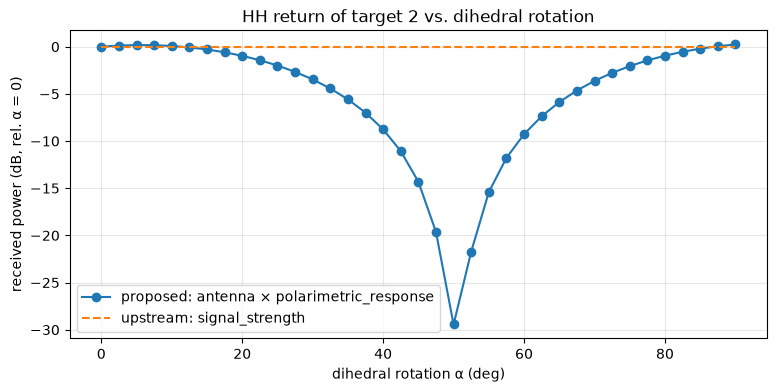

In [7]:
from dataclasses import replace

alphas = np.radians(np.arange(0.0, 90.1, 2.5))
hfss_power, legacy_power = [], []
for alpha in alphas:
    targets = [replace(t, scattering=toy_env.dihedral(alpha)) if t.id == 2 else t for t in toy_env.DEFAULT_TARGETS]
    reflection = next(r for r in toy_env.hfss_reflections(received_config, ground_truth, targets)
                      if abs(np.degrees(r.arrival_horizontal_angle) - 5.6) < 1)
    y = rx_snapshot(reflection, np.random.default_rng(2))
    hfss_power.append(bartlett(y).max())
    legacy = next(r for r in toy_env.legacy_reflections(received_config, ground_truth, targets)
                  if abs(np.degrees(r.source_horizontal_angle) - 5.6) < 1)
    legacy_power.append(10 ** (legacy.signal_strength / 10))

hfss_db = 10 * np.log10(np.array(hfss_power) / hfss_power[0])
legacy_db = 10 * np.log10(np.array(legacy_power) / legacy_power[0])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.degrees(alphas), hfss_db, "o-", label="proposed: antenna × polarimetric_response")
ax.plot(np.degrees(alphas), legacy_db, "--", label="upstream: signal_strength")
ax.set_xlabel("dihedral rotation α (deg)")
ax.set_ylabel("received power (dB, rel. α = 0)")
ax.set_title("HH return of target 2 vs. dihedral rotation")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

### 6. MIMO radar: virtual array from the same interface

AntennaModel: 2 element types, 7 elements, 1.06 MB


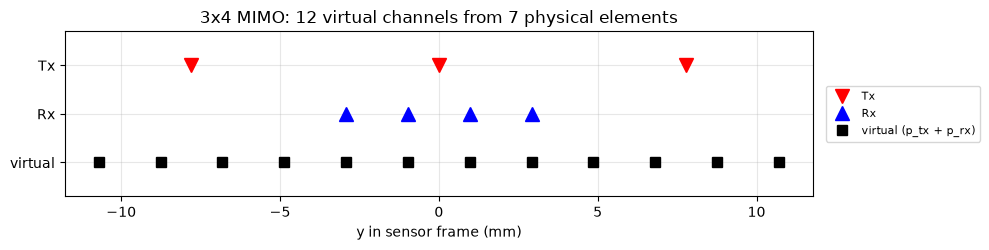

In [8]:
n_tx, n_rx = 3, 4
mimo_tx_y = (np.arange(n_tx) - (n_tx - 1) / 2) * n_rx * 0.5 * WAVELENGTH
mimo_rx_y = (np.arange(n_rx) - (n_rx - 1) / 2) * 0.5 * WAVELENGTH

mimo_elements = [
    AntennaElement(index=i, element_type_id=TX_TYPE, position=Vector3d(0.0, y, 0.0))
    for i, y in enumerate(mimo_tx_y)
]
mimo_elements += [
    AntennaElement(index=i, element_type_id=RX_TYPE, position=Vector3d(0.0, y, 0.0))
    for i, y in enumerate(mimo_rx_y)
]
mimo_model = AntennaModel(
    id=1,
    polarization_basis=PolarizationBasis.LINEAR_HV,
    element_type=element_types,
    element=mimo_elements,
)

mimo_config = RadarConfig()
mimo_config.CopyFrom(radar_config)
mimo_config.antenna_model.CopyFrom(to_proto(mimo_model.resampled(np.radians(2.0))))
print(f"AntennaModel: {len(mimo_config.antenna_model.element_type)} element types, "
      f"{len(mimo_config.antenna_model.element)} elements, {mimo_config.antenna_model.ByteSize() / 1e6:.2f} MB")

# Sensor side: rebuild the array from the serialised configuration only
received_mimo_config = RadarConfig.FromString(mimo_config.SerializeToString())
mimo_antenna = from_proto(received_mimo_config.antenna_model)
mimo_tx = mimo_antenna.elements(Mode.TRANSMIT)
mimo_rx = mimo_antenna.elements(Mode.RECEIVE)
virtual_y = np.array([tx.position.y + rx.position.y for tx in mimo_tx for rx in mimo_rx])
assert np.allclose(np.diff(virtual_y), 0.5 * WAVELENGTH)

fig, ax = plt.subplots(figsize=(10, 2.6))
ax.plot([e.position.y * 1e3 for e in mimo_tx], [2] * n_tx, "rv", markersize=10, label="Tx")
ax.plot([e.position.y * 1e3 for e in mimo_rx], [1] * n_rx, "b^", markersize=10, label="Rx")
ax.plot(virtual_y * 1e3, [0] * len(virtual_y), "ks", markersize=7, label="virtual (p_tx + p_rx)")
ax.set_yticks([0, 1, 2], ["virtual", "Rx", "Tx"])
ax.set_ylim(-0.7, 2.7)
ax.set_xlabel("y in sensor frame (mm)")
ax.set_title(f"{n_tx}x{n_rx} MIMO: {len(virtual_y)} virtual channels from {n_tx + n_rx} physical elements")
ax.grid(True, alpha=0.3)
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

Two cars at the same range and with the same velocity, 12° apart, fall into the same range–Doppler cell, so only the angular dimension can separate them. The Rayleigh resolution of an *N*-element λ/2 array at boresight is ≈ 2/*N* rad: 28.6° for the 4 physical Rx channels, 9.5° for the 12 virtual channels.

The two cars scatter with different phases (here 90° apart). Two point targets at *exactly* the same range with identical phase would be fully coherent and merge into one peak for any Bartlett beamformer; the scattering phase is carried by `polarimetric_response`.

The environment simulation is called exactly as before, with the MIMO configuration.

In [9]:
CLOSE_AZIMUTHS_DEG = (-6.0, 6.0)
SCATTERING_PHASES_DEG = (0.0, 90.0)  # independent scatterers -> different scattering phase
CLOSE_RANGE = 40.0
mount = radar_config.mounting_position.position
host_speed = 20.0

close_targets = [
    toy_env.Target(
        id=10 + i,
        position=(mount.x + CLOSE_RANGE * np.cos(np.radians(a)), CLOSE_RANGE * np.sin(np.radians(a)), mount.z),
        velocity=(host_speed, 0.0, 0.0),  # same velocity as host -> same Doppler cell
        dimension=(4.5, 1.8, 1.5),
        rcs_dbsm=10.0,
        scattering=toy_env.PLATE * np.exp(1j * np.radians(phi)),
    )
    for i, (a, phi) in enumerate(zip(CLOSE_AZIMUTHS_DEG, SCATTERING_PHASES_DEG))
]
close_ground_truth = toy_env.make_ground_truth(close_targets, host_speed=host_speed)
close_reflections = toy_env.hfss_reflections(received_mimo_config, close_ground_truth, close_targets)

for r in close_reflections:
    print(f"ToF {r.time_of_flight * 1e9:.2f} ns, doppler {r.doppler_shift:.1f} Hz, "
          f"arrival {np.degrees(r.arrival_horizontal_angle):.1f} deg")

ToF 266.85 ns, doppler -0.0 Hz, arrival -6.0 deg
ToF 266.85 ns, doppler -0.0 Hz, arrival 6.0 deg


For comparison the SIMO case uses Tx 0 only (4 channels). Doppler-induced phase between TDM slots is zero here (no relative motion); a real sensor model would compensate it.

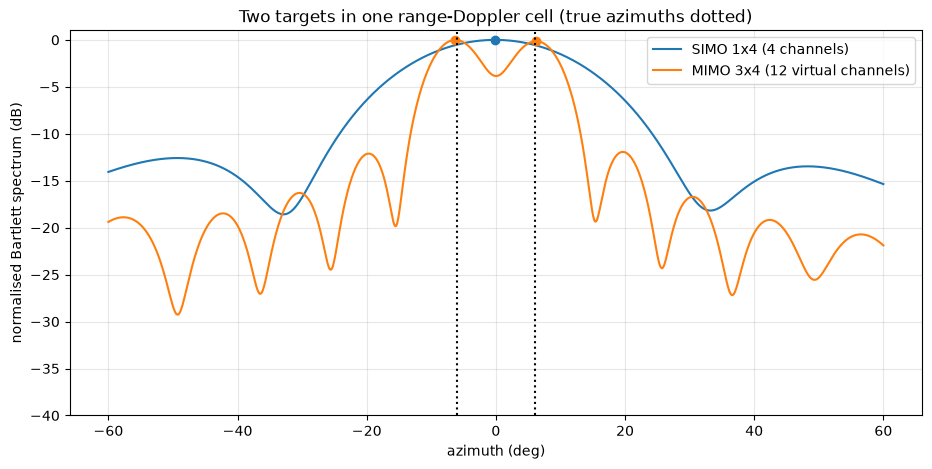

SIMO peaks: [-0.1]
MIMO peaks: [-6.3, 6.2]


In [10]:
def mimo_channel(antenna, reflection, tx_list, rx_list, tx_excitation=np.array([1.0, 0.0])):
    # Noise-free y[t, r] of one reflection, Tx t transmitting alone in TDM slot t
    S = toy_env.jones_from_osi(reflection.polarimetric_response)
    departure = Direction(reflection.source_horizontal_angle, reflection.source_vertical_angle)
    arrival = Direction(reflection.arrival_horizontal_angle, reflection.arrival_vertical_angle)
    rx_phase = [np.exp(1j * k * rx.position.to_array() @ arrival.unit_vector()) for rx in rx_list]
    y = np.zeros((len(tx_list), len(rx_list)), dtype=complex)
    for t, tx in enumerate(tx_list):
        field = (antenna.response(tx, frequency, departure, tx_excitation)
                 * np.exp(1j * k * tx.position.to_array() @ departure.unit_vector()))
        scattered = S @ field
        for r, rx in enumerate(rx_list):
            y[t, r] = antenna.receive(rx, frequency, arrival, scattered)[0] * rx_phase[r]
    return y * np.sqrt(tx_mw) * np.exp(-2j * np.pi * frequency * reflection.time_of_flight)


def virtual_steering(antenna, tx_list, rx_list, angles_deg):
    rows = []
    for a in angles_deg:
        direction = Direction(np.radians(a), 0.0)
        u = direction.unit_vector()
        g_tx = [antenna.jones(tx, frequency, direction)[0, 0] * np.exp(1j * k * tx.position.to_array() @ u)
                for tx in tx_list]
        g_rx = [antenna.jones(rx, frequency, direction)[0, 0] * np.exp(1j * k * rx.position.to_array() @ u)
                for rx in rx_list]
        rows.append(np.outer(g_tx, g_rx).ravel())
    return np.array(rows)


def spectrum(steering_matrix, y):
    return np.abs(steering_matrix.conj() @ y) ** 2 / np.sum(np.abs(steering_matrix) ** 2, axis=1)


def find_peaks(p, threshold_db=-6.0):
    db = 10 * np.log10(p / p.max())
    return [i for i in range(1, len(p) - 1) if p[i] > p[i - 1] and p[i] >= p[i + 1] and db[i] > threshold_db]


rng = np.random.default_rng(3)
Y = sum(mimo_channel(mimo_antenna, r, mimo_tx, mimo_rx) for r in close_reflections)
Y = Y + np.sqrt(noise_mw / 2) * (rng.standard_normal(Y.shape) + 1j * rng.standard_normal(Y.shape))

p_mimo = spectrum(virtual_steering(mimo_antenna, mimo_tx, mimo_rx, scan_deg), Y.ravel())
p_simo = spectrum(virtual_steering(mimo_antenna, mimo_tx[:1], mimo_rx, scan_deg), Y[0])
peaks_mimo, peaks_simo = find_peaks(p_mimo), find_peaks(p_simo)

fig, ax = plt.subplots(figsize=(11, 5))
for p, peaks, label in ((p_simo, peaks_simo, f"SIMO 1x{n_rx} ({n_rx} channels)"),
                        (p_mimo, peaks_mimo, f"MIMO {n_tx}x{n_rx} ({n_tx * n_rx} virtual channels)")):
    db = 10 * np.log10(p / p.max())
    line, = ax.plot(scan_deg, db, label=label)
    ax.plot(scan_deg[peaks], db[peaks], "o", color=line.get_color())
for a in CLOSE_AZIMUTHS_DEG:
    ax.axvline(a, color="k", linestyle=":")
ax.set_ylim(-40, 1)
ax.set_xlabel("azimuth (deg)")
ax.set_ylabel("normalised Bartlett spectrum (dB)")
ax.set_title("Two targets in one range-Doppler cell (true azimuths dotted)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

print("SIMO peaks:", np.round(scan_deg[peaks_simo], 1).tolist())
print("MIMO peaks:", np.round(scan_deg[peaks_mimo], 1).tolist())
assert len(peaks_simo) == 1
assert len(peaks_mimo) == 2
assert np.allclose(np.sort(scan_deg[peaks_mimo]), CLOSE_AZIMUTHS_DEG, atol=1.5)

The MIMO detections go into `SensorData` exactly as in step 4 — the output side of OSI is unaffected. What the interface has to provide for MIMO is only the complete element list with positions and complex patterns, which `AntennaModel` does, and an antenna-free channel per reflection, which `polarimetric_response` does.

In [11]:
mimo_radar_data = osi_featuredata_pb2.RadarDetectionData()
mimo_radar_data.header.CopyFrom(radar_data.header)
for peak in peaks_mimo:
    detection = mimo_radar_data.detection.add()
    detection.existence_probability = 1.0
    detection.position.distance = SPEED_OF_LIGHT * close_reflections[0].time_of_flight / 2
    detection.position.azimuth = np.radians(scan_deg[peak])
    detection.position.elevation = 0.0
    detection.snr = 10 * np.log10(p_mimo[peak] / noise_mw)
mimo_radar_data.header.number_of_valid_detections = len(mimo_radar_data.detection)

for d in mimo_radar_data.detection:
    print(f"range {d.position.distance:.2f} m, azimuth {np.degrees(d.position.azimuth):6.2f} deg, snr {d.snr:.1f} dB")

range 40.00 m, azimuth  -6.30 deg, snr 37.8 dB
range 40.00 m, azimuth   6.20 deg, snr 37.6 dB


### 7. Compatibility and open questions

**Compatibility**

- Only new optional fields / messages; field numbers 12–13 (`RadarSensorViewConfiguration`) and 6–8 (`Reflection`) are unused upstream. Old consumers ignore them.
- `antenna_application` unset ⇒ upstream behaviour (`ENVIRONMENT`): `signal_strength` contains the antenna diagrams, which should still be filled (derived from `antenna_model`, as shown in step 2).
- `SENSOR_MODEL` changes the meaning of `signal_strength` to antenna-free path gain; environment simulations that do not support it should leave `antenna_application` unset in their echoed `view_configuration`, so the sensor model can detect the fallback.

**Open questions**

- Pattern size: grid resolution vs. message size; external pattern references (file / URI + hash) or spherical-wave / harmonic coefficients instead of sampled grids.
- Interpolation rule between grid points and between `frequency_instance`s (wideband / chirp bandwidth).
- Whether ray tracers should also return per-ray phase beyond `time_of_flight` (e.g., material phase), currently covered by the phase of `polarimetric_response`.